## 1. Resumen del Tema de Investigación

* **Título:** *“Determinantes macroeconómicos y financieros del rendimiento bursátil del sector bancario en economías emergentes: Un análisis multifactorial para Credicorp Ltd. (2021-2026)”*.
* **Objetivo:** Evaluar y cuantificar el impacto que tienen las fuerzas del mercado local, el entorno financiero global y las materias primas sobre las variaciones del rendimiento logarítmico de la acción de Credicorp Ltd. ($BAP$). Esto permite entender qué tan vulnerable o resiliente es el holding financiero más grande del Perú ante choques macroeconómicos.

---

## 2. El Modelo Económico (Marco Teórico)

La investigaciòn se fundamenta en la **Teoría de Valoración por Arbitraje (APT)** desarrollada por **Stephen Ross (1976)** y en el modelo **CAPM de Sharpe (1964)**. La teoría APT sostiene que el rendimiento de un activo financiero no solo depende de un mercado general, sino de múltiples factores de riesgo sistemático independientes.

El modelo econométrico final (estimado por Mínimos Cuadrados Ordinarios) se plantea así:

$$R_{Credicorp, t} = \beta_0 + \beta_1 R_{Mercado\_Peru, t} + \beta_2 R_{Cobre, t} + \beta_3 R_{Financiero\_Global, t} + \varepsilon_t$$

---

## 3. Variables

### Variable endogena ($Y$)

* **Rendimiento de Credicorp ($R_{Credicorp}$):** Se utilizan los rendimientos logarítmicos continuos de la acción más líquida del holding financiero.

### Variables exogenas ($X$)

* **$R_{Mercado\_Peru}$ (Rendimiento del Mercado Local / ETF EPU):** 
  - *Justificación:* **Sharpe (1964) y Lintner (1965)** en el desarrollo del *Capital Asset Pricing Model (CAPM)*.
  - *Explicación:* Postulan que el rendimiento de cualquier acción está ligado intrínsecamente a la evolución de su mercado local (Riesgo Sistemático o Beta). Como viste en tus primeros resultados, es el factor con mayor peso y significancia debido a la alta correlación estructural de Credicorp con la economía peruana.


* **$R_{Financiero\_Global}$ (Rendimiento del Sector Financiero Global / ETF XLF):**
  - *Justificación:* **Flannery y James (1984)**, en su estudio pionero sobre la sensibilidad de las acciones bancarias a los factores de riesgo financiero y tasas de interés. Asimismo, los economistas de la **Reserva Federal (2025)** respaldan el uso de enfoques basados en factores sectoriales específicos para aislar el comportamiento de la banca del resto de industrias (como las tecnológicas).
  - *Explicación:* Credicorp no se mueve igual que una empresa industrial; al ser un banco, es altamente sensible al riesgo de contagio financiero internacional, la liquidez global y las políticas de tasas de interés de los bancos centrales.


* **$R_{Cobre}$ (Variación del Precio del Cobre / HG=F):**
  - *Justificación:* **Mendoza (1995)** y localmente investigaciones del **Banco Central de Reserva del Perú (BCRP, 2026)** sobre los efectos de los precios de los *commodities* en la estabilidad macroeconómica interna. También **Beck, Demirgüç-Kunt y Levine (2015)** explican que en economías emergentes dependientes de recursos primarios, los precios de las materias primas determinan la salud crediticia de los bancos.
  - *Explicación:* Al ser el cobre el principal producto de exportación de Perú, un incremento en su precio expande la economía real, reduce los ratios de morosidad de los clientes del banco (BCP, Mibanco) y eleva los márgenes de ganancia de Credicorp, impactando positivamente el precio de su acción.





In [60]:
import pandas as pd
import numpy as np
import yfinance as yf

# 1. Definimos un diccionario con el nombre que queremos y su Ticker de Yahoo
TICKERS = {
    'Credicorp': 'BAP',
    'Peru_Mercado': 'EPU',
    'Precio_cobre': 'HG=F',
    'ETF_XLF': 'XLF'
}

START_DATE = "2020-12-01"
END_DATE = "2025-12-31"

df_precios = pd.DataFrame()

print("Descargando datos...")

# Activos con datos mensuales directos
for nombre, ticker in TICKERS.items():
    data = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        interval="1d",
        auto_adjust=True,
        progress=False
    )

    precio = data['Close'].resample('ME').last()
    precio.index = precio.index.to_period('M')

    df_precios[nombre] = precio


# Limpiar filas donde se crucen días feriados o sin datos
df_precios = df_precios.dropna()

# 3. Transformar los precios a rendimientos logarítmicos
df_rendimientos = np.log(df_precios / df_precios.shift(1)).dropna()

# 4. Renombrar las columnas con el prefijo 'R_' para saber que son rendimientos
df_rendimientos.columns = ['R_Credicorp', 'R_Peru_Mercado', 'Precio_cobre', 'ETF_XLF']

# 5. Guardar el resultado en un CSV
df_rendimientos.to_csv("base_datos_econometria.csv")

print("\n¡Todo listo! Base de datos guardada como 'base_datos_econometria.csv'")
print(f"Total de registros listos para la regresión: {len(df_rendimientos)}")
print(df_rendimientos.head())

Descargando datos...

¡Todo listo! Base de datos guardada como 'base_datos_econometria.csv'
Total de registros listos para la regresión: 60
         R_Credicorp  R_Peru_Mercado  Precio_cobre   ETF_XLF
Date                                                        
2021-01    -0.087155       -0.010435      0.016791 -0.018142
2021-02     0.062403        0.077080      0.136099  0.109807
2021-03    -0.158399       -0.086742     -0.022601  0.056876
2021-04    -0.134358       -0.068804      0.112356  0.062885
2021-05     0.140927        0.036514      0.044432  0.046608


======= 1. COEFICIENTES Y 2. NIVEL DE SIGNIFICANCIA =======
                            OLS Regression Results                            
Dep. Variable:            R_Credicorp   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     55.69
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           8.21e-17
Time:                        00:34:49   Log-Likelihood:                 101.03
No. Observations:                  60   AIC:                            -194.1
Df Residuals:                      56   BIC:                            -185.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

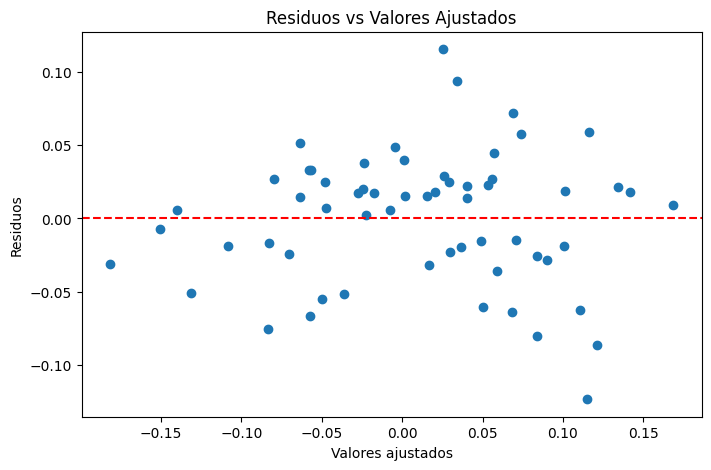

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.diagnostic as sms
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Cargar la base de datos (generada en el paso anterior)
df = pd.read_csv("base_datos_econometria.csv", index_col=0)

# Definir Variable Dependiente (Y) e Independientes (X)
y = df['R_Credicorp']
X = df[['R_Peru_Mercado', 'Precio_cobre', 'ETF_XLF']]

# ESENCIAL EN ECONOMETRÍA: Añadir la constante (Beta_0 o Intercepto)
X = sm.add_constant(X)

# 2. Ajustar el modelo de Regresión Múltiple (MCO / OLS)
modelo = sm.OLS(y, X).fit()

# Guardar los residuos (los necesitaremos para las pruebas de diagnóstico)
residuos = modelo.resid


# ==============================================================================
# IMPRESIÓN DE RESULTADOS
# ==============================================================================

print("======= 1. COEFICIENTES Y 2. NIVEL DE SIGNIFICANCIA =======")
print(modelo.summary())
print("\n" + "="*60 + "\n")

print("======= 3. PRUEBA DE NORMALIDAD (Jarque-Bera) =======")
jb_estadistico, p_valor = stats.jarque_bera(residuos)
print(f"Estadístico Jarque-Bera: {jb_estadistico:.4f}")
print(f"p-valor: {p_valor:.4f}")
if p_valor > 0.05:
    print("Resultado: No se rechaza H0. Los residuos se distribuyen NORMALMENTE.")
else:
    print("Resultado: Se rechaza H0. Los residuos NO se distribuyen normalmente.")
print("\n" + "="*60 + "\n")

print("======= 4. AUTOCORRELACIÓN =======")
# Durbin-Watson (ya viene en el summary, pero lo analizamos aquí)
dw = sm.stats.stattools.durbin_watson(residuos)
print(f"Estadístico Durbin-Watson: {dw:.4f}")
if 1.5 <= dw <= 2.5:
    print("Resultado (DW): No hay indicios graves de autocorrelación de primer orden.")
else:
    print("Resultado (DW): Alerta. Posible presencia de autocorrelación.")

# Prueba más robusta: Breusch-Godfrey (para autocorrelación de orden superior, ej. 2 rezagos)
bg_test = sms.acorr_breusch_godfrey(modelo, nlags=2)
bg_pvalue = bg_test[1]
print(f"p-valor (Breusch-Godfrey): {bg_pvalue:.4f}")
if bg_pvalue > 0.05:
    print("Resultado (BG): No hay autocorrelación en los residuos.")
else:
    print("Resultado (BG): Se rechaza H0. Existe AUTOCORRELACIÓN.")
print("\n" + "="*60 + "\n")

print("======= 5. HETEROCEDASTICIDAD (Breusch-Pagan) =======")
bp_test = sms.het_breuschpagan(residuos, X)
bp_pvalue = bp_test[1]
print(f"p-valor (Breusch-Pagan): {bp_pvalue:.4f}")
if bp_pvalue > 0.05:
    print("Resultado: No se rechaza H0. Los residuos son HOMOCEDÁSTICOS (Varianza constante).")
else:
    print("Resultado: Se rechaza H0. Los residuos sufren de HETEROCEDASTICIDAD.")

